In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Starting Robust Class-Specific Augmentation...
Target: 1500 samples per class
=== ROBUST CLASS-SPECIFIC AUGMENTATION ===
Target: 1500 samples per class
=== Validating Dataset ===

Validation Results:
Total images in CSV: 2930
Valid images found: 2930
Missing/corrupted images: 0

=== Augmentation Strategy (Target: 1500 per class) ===
Class | Current | Target | Need to Generate
---------------------------------------------
  0   |   1434  |  1500  |       66
  1   |    300  |  1500  |     1200
  2   |    808  |  1500  |      692
  3   |    154  |  1500  |     1346
  4   |    234  |  1500  |     1266

Total samples to generate: 4570

Generating 66 samples for Class 0 (from 1434 source images)


Class 0: 100%|██████████| 66/66 [00:35<00:00,  1.84it/s, Success=66]


Class 0: Successfully generated 66/66 samples

Generating 1200 samples for Class 1 (from 300 source images)


Class 1: 100%|██████████| 1200/1200 [13:50<00:00,  1.44it/s, Success=1200]


Class 1: Successfully generated 1200/1200 samples

Generating 692 samples for Class 2 (from 808 source images)


...

Class 3: Successfully generated 1346/1346 samples

Generating 1266 samples for Class 4 (from 234 source images)


Class 4: 100%|██████████| 1266/1266 [21:17<00:00,  1.01s/it, Success=1266]


Class 4: Successfully generated 1266/1266 samples

=== Creating Final Dataset ===

=== Final Validation ===

=== FINAL RESULTS ===
Original valid samples: 2930
Generated samples: 4570
Final dataset size: 7500

Final class distribution:
Class 0: 1500 samples
Class 1: 1500 samples
Class 2: 1500 samples
Class 3: 1500 samples
Class 4: 1500 samples

=== FINAL VERIFICATION ===


Verifying: 100%|██████████| 7500/7500 [00:05<00:00, 1417.15it/s]



Verification complete:
Total entries in CSV: 7500
Missing images: 0
Success rate: 100.00%


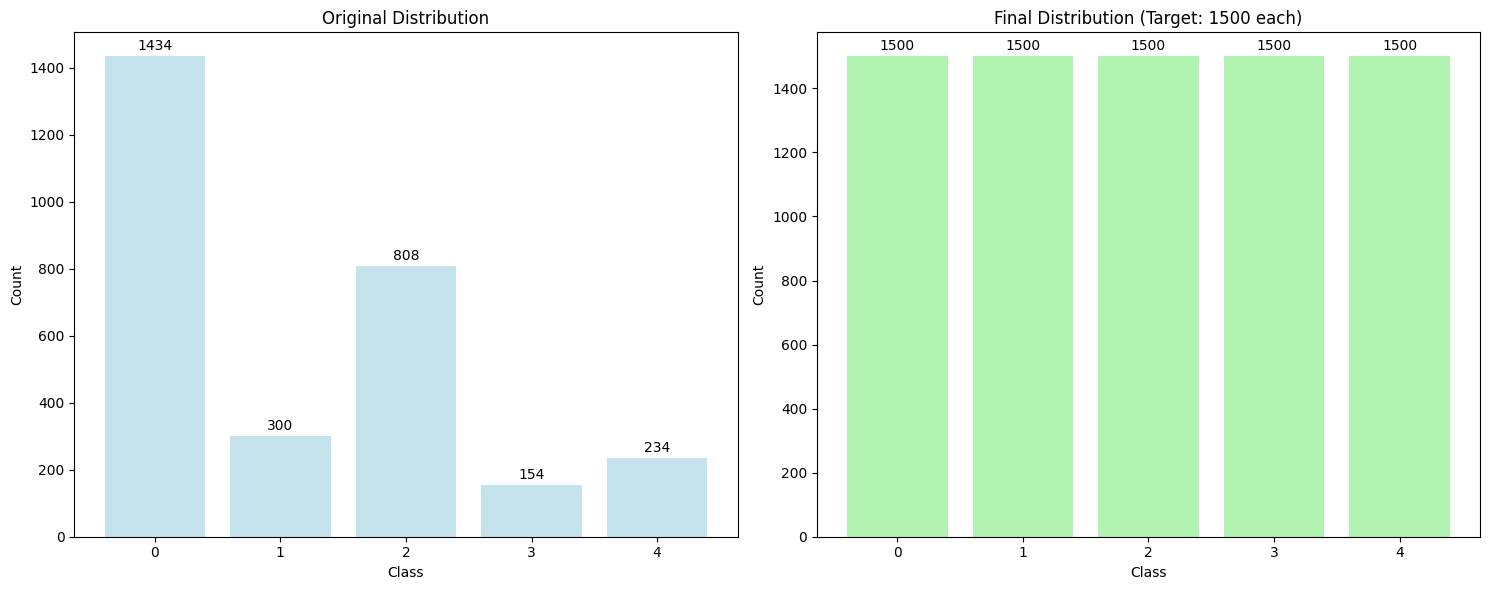


✅ SUCCESS: All images properly generated and mapped!

📁 Files created:
   - Updated CSV: /content/drive/MyDrive/capstone/aptos2019/updated_train.csv
   - Augmented images: /content/drive/MyDrive/capstone/aptos2019/augmented_images


In [2]:
import os
import pandas as pd
import cv2
import numpy as np
import uuid
import matplotlib.pyplot as plt
import albumentations as A
from tqdm import tqdm
import seaborn as sns

# Your existing setup
DATASET_DIR = "/content/drive/MyDrive/capstone/aptos2019"
TRAIN_CSV = os.path.join(DATASET_DIR, "train_1.csv")
TRAIN_IMG_DIR = os.path.join(DATASET_DIR, "train_images/train_images")
AUGMENTED_IMG_DIR = os.path.join(DATASET_DIR, "augmented_images")
UPDATED_CSV = os.path.join(DATASET_DIR, "updated_train.csv")

# Create augmented images directory
os.makedirs(AUGMENTED_IMG_DIR, exist_ok=True)

# Load your data
df = pd.read_csv(TRAIN_CSV)

# Your specific augmentation pipeline
augmentation_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.RandomGamma(p=0.2),
    A.Rotate(limit=30, p=0.3),
    A.RandomResizedCrop(size=(256, 256), scale=(0.5, 1.0), ratio=(0.75, 1.33), p=0.5),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.5),
])

def verify_image_exists(img_id, img_dir):
    """
    Verify if image file exists with proper extension
    """
    # Check common extensions
    for ext in ['.png', '.jpg', '.jpeg']:
        img_path = os.path.join(img_dir, f"{img_id}{ext}")
        if os.path.exists(img_path):
            return img_path
    return None

def load_and_validate_image(img_path):
    """
    Load image and validate it's readable
    """
    try:
        img = cv2.imread(img_path)
        if img is None:
            print(f"Warning: Could not load image {img_path}")
            return None

        # Convert BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return img
    except Exception as e:
        print(f"Error loading {img_path}: {e}")
        return None

def validate_dataset():
    """
    Validate that all images in CSV actually exist
    """
    print("=== Validating Dataset ===")
    missing_images = []
    valid_images = []

    for idx, row in df.iterrows():
        img_id = row['id_code']
        img_path = verify_image_exists(img_id, TRAIN_IMG_DIR)

        if img_path is None:
            missing_images.append(img_id)
            print(f"Missing: {img_id}")
        else:
            # Test if image can be loaded
            img = load_and_validate_image(img_path)
            if img is not None:
                valid_images.append(img_id)
            else:
                missing_images.append(img_id)

    print(f"\nValidation Results:")
    print(f"Total images in CSV: {len(df)}")
    print(f"Valid images found: {len(valid_images)}")
    print(f"Missing/corrupted images: {len(missing_images)}")

    if missing_images:
        print(f"Missing images: {missing_images[:10]}...")  # Show first 10

    # Return only valid data
    valid_df = df[df['id_code'].isin(valid_images)].copy()
    return valid_df

def calculate_augmentation_targets(valid_df, target_per_class=1500):
    """
    Calculate how many samples to generate for each class
    """
    current_counts = valid_df['diagnosis'].value_counts().sort_index()

    print(f"\n=== Augmentation Strategy (Target: {target_per_class} per class) ===")
    print("Class | Current | Target | Need to Generate")
    print("-" * 45)

    augment_needed = {}
    for class_id in range(5):
        current = current_counts.get(class_id, 0)
        target = target_per_class
        needed = max(0, target - current)
        augment_needed[class_id] = needed

        print(f"  {class_id}   |   {current:4d}  |  {target:4d}  |     {needed:4d}")

    total_to_generate = sum(augment_needed.values())
    print(f"\nTotal samples to generate: {total_to_generate}")

    return augment_needed

def generate_augmented_samples_for_class(class_id, num_needed, valid_df, aug_pipeline):
    """
    Generate augmented samples for a specific class with proper ID mapping
    """
    if num_needed == 0:
        print(f"Class {class_id}: No augmentation needed")
        return []

    # Get all valid images for this class
    class_data = valid_df[valid_df['diagnosis'] == class_id]
    class_images = class_data['id_code'].tolist()

    if len(class_images) == 0:
        print(f"Warning: No images found for class {class_id}")
        return []

    print(f"\nGenerating {num_needed} samples for Class {class_id} (from {len(class_images)} source images)")

    augmented_records = []
    successful_generations = 0

    pbar = tqdm(range(num_needed), desc=f"Class {class_id}")

    for i in pbar:
        max_attempts = 5
        success = False

        for attempt in range(max_attempts):
            try:
                # Select random source image
                source_id = np.random.choice(class_images)
                source_path = verify_image_exists(source_id, TRAIN_IMG_DIR)

                if source_path is None:
                    continue

                # Load source image
                img = load_and_validate_image(source_path)
                if img is None:
                    continue

                # Apply augmentation
                augmented = aug_pipeline(image=img)
                aug_img = augmented['image']

                # Generate unique, trackable ID
                aug_id = f"aug_c{class_id}_{i:05d}_{successful_generations:05d}"

                # Save augmented image
                aug_path = os.path.join(AUGMENTED_IMG_DIR, f"{aug_id}.png")

                # Convert RGB back to BGR for saving
                aug_img_bgr = cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR)

                # Save with high quality
                cv2.imwrite(aug_path, aug_img_bgr, [cv2.IMWRITE_PNG_COMPRESSION, 3])

                # Verify the saved image exists and is readable
                if os.path.exists(aug_path):
                    test_img = cv2.imread(aug_path)
                    if test_img is not None:
                        # Record successful augmentation
                        augmented_records.append({
                            'id_code': aug_id,
                            'diagnosis': class_id,
                            'source_image': source_id,
                            'is_augmented': True
                        })
                        successful_generations += 1
                        success = True
                        break
                    else:
                        os.remove(aug_path)  # Remove corrupted file

            except Exception as e:
                print(f"Error in attempt {attempt + 1}: {e}")
                continue

        if not success:
            print(f"Failed to generate augmented sample {i} for class {class_id}")

        pbar.set_postfix({'Success': successful_generations})

    print(f"Class {class_id}: Successfully generated {successful_generations}/{num_needed} samples")
    return augmented_records

def create_balanced_dataset(target_per_class=1500):
    """
    Main function to create balanced dataset
    """
    print("=== ROBUST CLASS-SPECIFIC AUGMENTATION ===")
    print(f"Target: {target_per_class} samples per class")

    # Step 1: Validate existing dataset
    valid_df = validate_dataset()

    if len(valid_df) == 0:
        print("ERROR: No valid images found!")
        return None

    # Step 2: Calculate augmentation needs
    augment_needed = calculate_augmentation_targets(valid_df, target_per_class)

    # Step 3: Generate augmented samples
    all_augmented_records = []

    for class_id in range(5):
        if augment_needed[class_id] > 0:
            class_records = generate_augmented_samples_for_class(
                class_id,
                augment_needed[class_id],
                valid_df,
                augmentation_pipeline
            )
            all_augmented_records.extend(class_records)

    # Step 4: Create final dataset
    print("\n=== Creating Final Dataset ===")

    # Prepare original data
    original_df = valid_df.copy()
    original_df['source_image'] = original_df['id_code']
    original_df['is_augmented'] = False

    # Combine with augmented data
    if all_augmented_records:
        augmented_df = pd.DataFrame(all_augmented_records)
        final_df = pd.concat([original_df, augmented_df], ignore_index=True)
    else:
        final_df = original_df

    # Step 5: Final validation - ensure all images exist
    print("\n=== Final Validation ===")
    final_missing = []

    for idx, row in final_df.iterrows():
        img_id = row['id_code']
        is_aug = row['is_augmented']

        if is_aug:
            img_path = os.path.join(AUGMENTED_IMG_DIR, f"{img_id}.png")
        else:
            img_path = verify_image_exists(img_id, TRAIN_IMG_DIR)

        if img_path is None or not os.path.exists(img_path):
            final_missing.append(img_id)

    if final_missing:
        print(f"Warning: {len(final_missing)} images still missing after generation")
        # Remove missing entries
        final_df = final_df[~final_df['id_code'].isin(final_missing)]

    # Save final dataset
    final_df.to_csv(UPDATED_CSV, index=False)

    # Results summary
    print(f"\n=== FINAL RESULTS ===")
    print(f"Original valid samples: {len(valid_df)}")
    print(f"Generated samples: {len(all_augmented_records)}")
    print(f"Final dataset size: {len(final_df)}")

    final_distribution = final_df['diagnosis'].value_counts().sort_index()
    print(f"\nFinal class distribution:")
    for class_id in range(5):
        count = final_distribution.get(class_id, 0)
        print(f"Class {class_id}: {count} samples")

    return final_df

def verify_final_dataset(final_df):
    """
    Final verification that all images in CSV exist
    """
    print("\n=== FINAL VERIFICATION ===")
    missing_count = 0

    for idx, row in tqdm(final_df.iterrows(), total=len(final_df), desc="Verifying"):
        img_id = row['id_code']
        is_aug = row['is_augmented']

        if is_aug:
            img_path = os.path.join(AUGMENTED_IMG_DIR, f"{img_id}.png")
        else:
            img_path = verify_image_exists(img_id, TRAIN_IMG_DIR)

        if img_path is None or not os.path.exists(img_path):
            missing_count += 1
            print(f"MISSING: {img_id}")

    print(f"\nVerification complete:")
    print(f"Total entries in CSV: {len(final_df)}")
    print(f"Missing images: {missing_count}")
    print(f"Success rate: {((len(final_df) - missing_count) / len(final_df) * 100):.2f}%")

    return missing_count == 0

def plot_distribution_comparison(original_df, final_df):
    """
    Plot before and after distribution
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Original
    orig_counts = original_df['diagnosis'].value_counts().sort_index()
    bars1 = axes[0].bar(orig_counts.index, orig_counts.values, color='lightblue', alpha=0.7)
    axes[0].set_title('Original Distribution')
    axes[0].set_xlabel('Class')
    axes[0].set_ylabel('Count')

    for bar in bars1:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 10,
                    f'{int(height)}', ha='center', va='bottom')

    # Final
    final_counts = final_df['diagnosis'].value_counts().sort_index()
    bars2 = axes[1].bar(final_counts.index, final_counts.values, color='lightgreen', alpha=0.7)
    axes[1].set_title('Final Distribution (Target: 1500 each)')
    axes[1].set_xlabel('Class')
    axes[1].set_ylabel('Count')

    for bar in bars2:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height + 10,
                    f'{int(height)}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

# Main execution
if __name__ == "__main__":
    print("Starting Robust Class-Specific Augmentation...")
    print("Target: 1500 samples per class")
    print("=" * 50)

    # Create balanced dataset
    final_df = create_balanced_dataset(target_per_class=1500)

    if final_df is not None:
        # Verify everything is working
        verification_passed = verify_final_dataset(final_df)

        # Plot results
        plot_distribution_comparison(df, final_df)

        if verification_passed:
            print("\n✅ SUCCESS: All images properly generated and mapped!")
        else:
            print("\n⚠️  Some issues detected. Check the verification output above.")

        print(f"\n📁 Files created:")
        print(f"   - Updated CSV: {UPDATED_CSV}")
        print(f"   - Augmented images: {AUGMENTED_IMG_DIR}")

    else:
        print("\n❌ FAILED: Could not create balanced dataset")

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T
from transformers import DetrForObjectDetection, DetrConfig
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from tqdm import tqdm

torch.manual_seed(42)

DATASET_DIR = "/content/drive/MyDrive/capstone/aptos2019"
TRAIN_CSV = "/content/drive/MyDrive/capstone/aptos2019/updated_train.csv"
AUGMENTED_IMG_DIR = "/content/drive/MyDrive/capstone/aptos2019/augmented_images"
TRAIN_IMG_DIR = os.path.join(DATASET_DIR, "train_images/train_images")
MODEL_SAVE_PATH = "/content/trained_model_detr.pth"

BATCH_SIZE = 8
NUM_EPOCHS = 11
LEARNING_RATE = 1e-4
NUM_CLASSES = 5
IMG_SIZE = 256
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 2

print(f"Using device: {DEVICE}")


class MobileNetBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        mobilenet = models.mobilenet_v2(weights="IMAGENET1K_V1")
        self.features = mobilenet.features
        self.out_channels = 1280

    def forward(self, x):
        return self.features(x)

class RetinopathyClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.mobilenet_v2(weights="IMAGENET1K_V1")


        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


class APTOSDataset(Dataset):
    def __init__(self, csv_file, train_img_dir, augmented_img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.train_img_dir = train_img_dir
        self.augmented_img_dir = augmented_img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_id = self.data.iloc[idx]['id_code']
        label = self.data.iloc[idx]['diagnosis']
        is_augmented = self.data.iloc[idx]['is_augmented']

        # Use the is_augmented column from CSV (it's reliable!)
        if is_augmented:
            # Try both .npy and .png for augmented images
            npy_path = os.path.join(self.augmented_img_dir, f"{img_id}.npy")
            png_path = os.path.join(self.augmented_img_dir, f"{img_id}.png")

            if os.path.exists(npy_path):
                try:
                    img_array = np.load(npy_path)
                    # Handle array format
                    if len(img_array.shape) == 3 and img_array.shape[0] == 3:
                        img_array = np.transpose(img_array, (1, 2, 0))
                    if img_array.dtype == np.float32 and img_array.max() <= 1.0:
                        img_array = (img_array * 255).astype(np.uint8)
                    image = Image.fromarray(img_array.astype(np.uint8))
                except Exception as e:
                    print(f"Error loading npy {img_id}: {e}")
                    image = torch.zeros((3, IMG_SIZE, IMG_SIZE))
            elif os.path.exists(png_path):
                try:
                    image = Image.open(png_path).convert('RGB')
                except Exception as e:
                    print(f"Error loading png {img_id}: {e}")
                    image = torch.zeros((3, IMG_SIZE, IMG_SIZE))
            else:
                print(f"Warning: Augmented image {img_id} not found (.npy or .png)")
                image = torch.zeros((3, IMG_SIZE, IMG_SIZE))
        else:
            # Load original image from train directory
            img_path = os.path.join(self.train_img_dir, f"{img_id}.png")
            if os.path.exists(img_path):
                try:
                    image = Image.open(img_path).convert('RGB')
                except Exception as e:
                    print(f"Error loading train image {img_id}: {e}")
                    image = torch.zeros((3, IMG_SIZE, IMG_SIZE))
            else:
                print(f"Warning: Train image {img_id}.png not found")
                image = torch.zeros((3, IMG_SIZE, IMG_SIZE))

        # Apply transforms
        if self.transform and not isinstance(image, torch.Tensor):
            image = self.transform(image)

        return image, label

transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


dataset = APTOSDataset(
    csv_file=TRAIN_CSV,
    train_img_dir=TRAIN_IMG_DIR,
    augmented_img_dir=AUGMENTED_IMG_DIR,
    transform=transform
)


print(f"Dataset size: {len(dataset)}")


train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

print(f"Train set: {len(train_dataset)} samples")
print(f"Validation set: {len(val_dataset)} samples")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)


model = RetinopathyClassifier(num_classes=NUM_CLASSES)
model = model.to(DEVICE)


criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2,)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training")
    for images, labels in progress_bar:

        images = images.to(device)
        labels = labels.to(device)


        optimizer.zero_grad()


        outputs = model(images)
        loss = criterion(outputs, labels)


        loss.backward()
        optimizer.step()


        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()


        progress_bar.set_postfix(
            loss=running_loss/len(progress_bar),
            acc=100.*correct/total
        )

    return running_loss / len(loader), correct / total


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        progress_bar = tqdm(loader, desc="Validation")
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            progress_bar.set_postfix(
                loss=running_loss/len(progress_bar),
                acc=100.*correct/total
            )

    return running_loss / len(loader), correct / total


history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0

print(f"Starting training on {DEVICE}...")
for epoch in range(NUM_EPOCHS):
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc = validate(model, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, MODEL_SAVE_PATH)
        print(f"Model saved to {MODEL_SAVE_PATH}")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

print("Training completed!")


def predict_image(model, image_path, transform, device):

    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)


    model.eval()


    with torch.no_grad():
        output = model(img_tensor)
        _, predicted = output.max(1)

    return predicted.item()

# Example usage (uncomment when ready to test)
# test_image_path = os.path.join(TRAIN_IMG_DIR, "some_image_id.png")
# prediction = predict_image(model, test_image_path, transform, DEVICE)
# print(f"Predicted class: {prediction}")

Using device: cpu
Dataset size: 7500
Train set: 6000 samples
Validation set: 1500 samples
Starting training on cpu...
Epoch 1/11


Training:   1%|          | 7/750 [00:16<23:49,  1.92s/it, acc=21.4, loss=0.0151]